In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Sales Analytics Project Started")

Sales Analytics Project Started


# Sales Performance Analytics

## 1. Project Overview

This project analyzes business sales data to identify revenue trends, top-performing products, profitable categories, and regional performance.

The analysis is designed to generate actionable business insights and recommendations that can support better sales and growth decisions.


## 2. Business Objective

The objective of this analysis is to:

- Identify products generating the highest revenue.
- Analyze sales trends over time.
- Identify high-performing and profitable categories.
- Compare sales and profitability across regions.
- Identify areas with growth opportunities.
- Provide actionable recommendations based on the analysis.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully.")

Libraries imported successfully.


In [15]:
file_path = "../data/raw/Sample - Superstore.csv"

df = pd.read_csv(file_path, encoding="latin1")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [16]:
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Dataset Shape:
(9994, 21)

Column Names:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

Data Types:
Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code        int64
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object


In [17]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [18]:
print("Duplicate Rows:")
print(df.duplicated().sum())

Duplicate Rows:
0


In [19]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## 6. Data Cleaning

The raw sales dataset is cleaned and prepared for analysis by checking for duplicate records, missing values, incorrect data types, and inconsistent date formats.

In [20]:
# Check the number of duplicate rows
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [21]:
# Check missing values in each column
missing_values = df.isnull().sum()

print(missing_values[missing_values > 0])

Series([], dtype: int64)


In [22]:
# Check the current data types
df.dtypes

Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code        int64
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

In [23]:
# Convert date columns to datetime format
df["Order Date"] = pd.to_datetime(df["Order Date"], errors="coerce")
df["Ship Date"] = pd.to_datetime(df["Ship Date"], errors="coerce")

print("Date columns converted successfully.")

Date columns converted successfully.


In [24]:
print(df[["Order Date", "Ship Date"]].dtypes)

Order Date    datetime64[us]
Ship Date     datetime64[us]
dtype: object


## 7. Feature Engineering

Additional time-based and profitability metrics are created to support deeper sales performance analysis.

In [25]:
# Create time-based features
df["Order Year"] = df["Order Date"].dt.year
df["Order Month"] = df["Order Date"].dt.month
df["Order Month Name"] = df["Order Date"].dt.month_name()
df["Quarter"] = df["Order Date"].dt.quarter

# Create profit margin
df["Profit Margin"] = (df["Profit"] / df["Sales"]) * 100

print("Feature engineering completed.")

Feature engineering completed.


In [26]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Order Year,Order Month,Order Month Name,Quarter,Profit Margin
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11,November,4,16.00
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11,November,4,30.00
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,6,June,2,47.00
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10,October,4,-40.00
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,10,October,4,11.25


In [27]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 9994
Columns: 26


## 8. Exploratory Data Analysis

This section explores sales performance across products, categories, regions, and time periods to identify important business patterns and opportunities.

## 9. KPI Analysis

Key performance indicators are calculated to understand the overall health of the business.

In [28]:
# Calculate key business KPIs

total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
total_orders = df["Order ID"].nunique()
total_quantity = df["Quantity"].sum()
profit_margin = (total_profit / total_sales) * 100
average_order_value = total_sales / total_orders

print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Total Quantity Sold: {total_quantity:,}")
print(f"Profit Margin: {profit_margin:.2f}%")
print(f"Average Order Value: ${average_order_value:,.2f}")

Total Sales: $2,297,200.86
Total Profit: $286,397.02
Total Orders: 5,009
Total Quantity Sold: 37,873
Profit Margin: 12.47%
Average Order Value: $458.61


## 10. Product Performance

Product-level analysis is used to identify the products generating the highest sales and the products contributing the most profit.

In [29]:
# Top 10 products by sales

top_products = (
    df.groupby("Product Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64

In [30]:
# Top 10 products by profit

top_profit_products = (
    df.groupby("Product Name")["Profit"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_profit_products

Product Name
Canon imageCLASS 2200 Advanced Copier                                          25199.9280
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind     7753.0390
Hewlett Packard LaserJet 3310 Copier                                            6983.8836
Canon PC1060 Personal Laser Copier                                              4570.9347
HP Designjet T520 Inkjet Large Format Printer - 24" Color                       4094.9766
Ativa V4110MDD Micro-Cut Shredder                                               3772.9461
3D Systems Cube Printer, 2nd Generation, Magenta                                3717.9714
Plantronics Savi W720 Multi-Device Wireless Headset System                      3696.2820
Ibico EPK-21 Electric Binding System                                            3345.2823
Zebra ZM400 Thermal Label Printer                                               3343.5360
Name: Profit, dtype: float64

## 11. Category Performance

Category-level analysis is performed to identify which product categories generate the highest sales and profit.

In [31]:
# Sales and profit by category

category_performance = (
    df.groupby("Category")
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Profit", "sum")
    )
    .sort_values("Total_Sales", ascending=False)
)

category_performance

,Total_Sales,Total_Profit
Category,,
Technology,836154.0330,145454.9481
Furniture,741999.7953,18451.2728
Office Supplies,719047.0320,122490.8008


## 12. Regional Performance

Regional performance is analyzed to identify geographic areas generating the highest sales and profit and to identify regions with potential growth opportunities.

In [32]:
# Sales and profit by region

regional_performance = (
    df.groupby("Region")
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Profit", "sum")
    )
    .sort_values("Total_Sales", ascending=False)
)

regional_performance

,Total_Sales,Total_Profit
Region,,
West,725457.8245,108418.4489
East,678781.2400,91522.7800
Central,501239.8908,39706.3625
South,391721.9050,46749.4303


In [33]:
# Rank regions by profit

regional_profit = (
    df.groupby("Region")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

regional_profit

Region
West       108418.4489
East        91522.7800
South       46749.4303
Central     39706.3625
Name: Profit, dtype: float64

In [34]:
# Top 10 states by sales

top_states = (
    df.groupby("State")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_states

State
California      457687.6315
New York        310876.2710
Texas           170188.0458
Washington      138641.2700
Pennsylvania    116511.9140
Florida          89473.7080
Illinois         80166.1010
Ohio             78258.1360
Michigan         76269.6140
Virginia         70636.7200
Name: Sales, dtype: float64

In [35]:
# Top 10 states by profit

top_profit_states = (
    df.groupby("State")["Profit"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_profit_states

State
California    76381.3871
New York      74038.5486
Washington    33402.6517
Michigan      24463.1876
Virginia      18597.9504
Indiana       18382.9363
Georgia       16250.0433
Kentucky      11199.6966
Minnesota     10823.1874
Delaware       9977.3748
Name: Profit, dtype: float64

## 13. Time-Based Analysis

Sales performance is analyzed over time to identify monthly and yearly trends, seasonal patterns, and periods of growth or decline.

In [36]:
# Yearly sales and profit

yearly_performance = (
    df.groupby("Order Year")
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Profit", "sum")
    )
)

yearly_performance

,Total_Sales,Total_Profit
Order Year,,
2014,484247.4981,49543.9741
2015,470532.5090,61618.6037
2016,609205.5980,81795.1743
2017,733215.2552,93439.2696


In [37]:
# Monthly sales trend

monthly_sales = (
    df.groupby("Order Month Name")["Sales"]
    .sum()
)

monthly_sales

Order Month Name
April        137762.1286
August       159044.0630
December     325293.5035
February      59751.2514
January       94924.8356
July         147238.0970
June         152718.6793
March        205005.4888
May          155028.8117
November     352461.0710
October      200322.9847
September    307649.9457
Name: Sales, dtype: float64

In [38]:
# Monthly sales in calendar order

month_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

monthly_sales = (
    df.groupby("Order Month Name")["Sales"]
    .sum()
    .reindex(month_order)
)

monthly_sales

Order Month Name
January       94924.8356
February      59751.2514
March        205005.4888
April        137762.1286
May          155028.8117
June         152718.6793
July         147238.0970
August       159044.0630
September    307649.9457
October      200322.9847
November     352461.0710
December     325293.5035
Name: Sales, dtype: float64

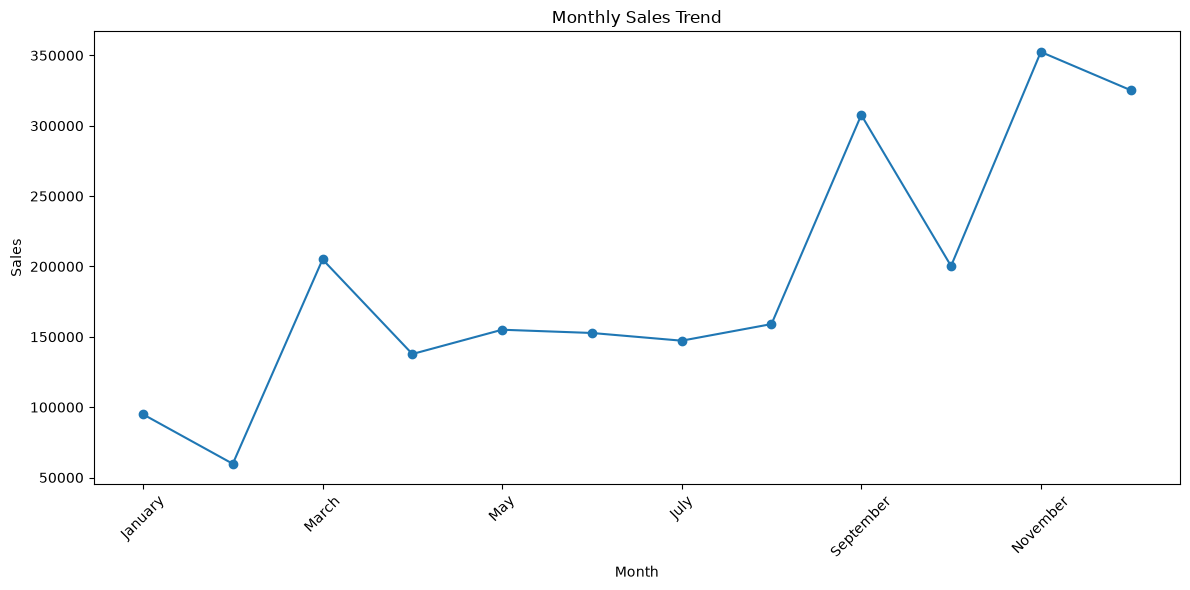

In [39]:
plt.figure(figsize=(12, 6))

monthly_sales.plot(kind="line", marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

## 14. Key Business Insights

The analysis results are interpreted from a business perspective to identify revenue drivers, profitability patterns, regional opportunities, and potential areas for improvement.

In [40]:
best_category = category_performance["Total_Sales"].idxmax()
best_category_sales = category_performance["Total_Sales"].max()

print("Highest-Selling Category:", best_category)
print(f"Sales Generated: ${best_category_sales:,.2f}")

Highest-Selling Category: Technology
Sales Generated: $836,154.03


In [41]:
most_profitable_category = category_performance["Total_Profit"].idxmax()
highest_category_profit = category_performance["Total_Profit"].max()

print("Most Profitable Category:", most_profitable_category)
print(f"Profit Generated: ${highest_category_profit:,.2f}")

Most Profitable Category: Technology
Profit Generated: $145,454.95


In [42]:
best_region = regional_performance["Total_Sales"].idxmax()
best_region_sales = regional_performance["Total_Sales"].max()

print("Highest-Selling Region:", best_region)
print(f"Sales Generated: ${best_region_sales:,.2f}")

Highest-Selling Region: West
Sales Generated: $725,457.82


In [43]:
most_profitable_region = regional_performance["Total_Profit"].idxmax()
highest_region_profit = regional_performance["Total_Profit"].max()

print("Most Profitable Region:", most_profitable_region)
print(f"Profit Generated: ${highest_region_profit:,.2f}")

Most Profitable Region: West
Profit Generated: $108,418.45


In [44]:
best_product = top_products.index[0]
best_product_sales = top_products.iloc[0]

print("Top-Selling Product:", best_product)
print(f"Sales Generated: ${best_product_sales:,.2f}")

Top-Selling Product: Canon imageCLASS 2200 Advanced Copier
Sales Generated: $61,599.82


In [45]:
most_profitable_product = top_profit_products.index[0]
most_product_profit = top_profit_products.iloc[0]

print("Most Profitable Product:", most_profitable_product)
print(f"Profit Generated: ${most_product_profit:,.2f}")

Most Profitable Product: Canon imageCLASS 2200 Advanced Copier
Profit Generated: $25,199.93


## 15. Recommendations

Based on the analysis, the following recommendations can be considered:

1. Prioritize high-performing products and categories by ensuring adequate inventory and marketing support.

2. Investigate products with high sales but relatively low profit margins to identify opportunities for pricing, discount, or cost optimization.

3. Focus growth initiatives on regions demonstrating strong sales and profitability.

4. Review underperforming regions and categories to identify whether pricing, discounts, product mix, or demand conditions are affecting performance.

5. Use monthly sales trends to improve inventory planning, promotional campaigns, and resource allocation during high-demand periods.

6. Monitor product-level profitability alongside revenue to ensure that revenue growth translates into sustainable business profit.

## 16. Export Clean Dataset

The cleaned and enhanced dataset is exported for use in the Power BI dashboard and further analysis.

In [46]:
# Export the cleaned dataset

output_path = "../data/processed/superstore_cleaned.csv"

df.to_csv(output_path, index=False)

print(f"Cleaned dataset exported to: {output_path}")

Cleaned dataset exported to: ../data/processed/superstore_cleaned.csv


# Dashboard Visualizations

The following visualizations present key business performance indicators and trends identified during the analysis.

In [47]:
# Executive KPI Summary

print("=" * 50)
print("SALES PERFORMANCE — EXECUTIVE SUMMARY")
print("=" * 50)

print(f"Total Sales       : ${total_sales:,.2f}")
print(f"Total Profit      : ${total_profit:,.2f}")
print(f"Total Orders      : {total_orders:,}")
print(f"Total Quantity    : {total_quantity:,}")
print(f"Profit Margin     : {profit_margin:.2f}%")
print(f"Average Order Value: ${average_order_value:,.2f}")

print("=" * 50)

SALES PERFORMANCE — EXECUTIVE SUMMARY
Total Sales       : $2,297,200.86
Total Profit      : $286,397.02
Total Orders      : 5,009
Total Quantity    : 37,873
Profit Margin     : 12.47%
Average Order Value: $458.61


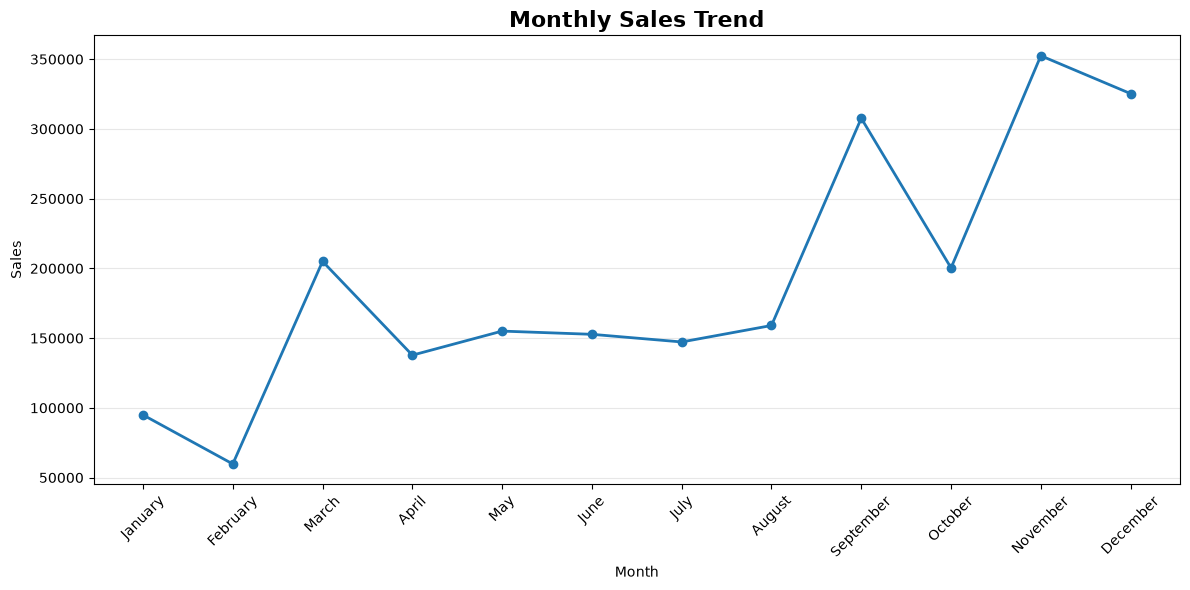

In [48]:
# Monthly Sales Trend

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o",
    linewidth=2
)

plt.title("Monthly Sales Trend", fontsize=16, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../screenshots/monthly_sales_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

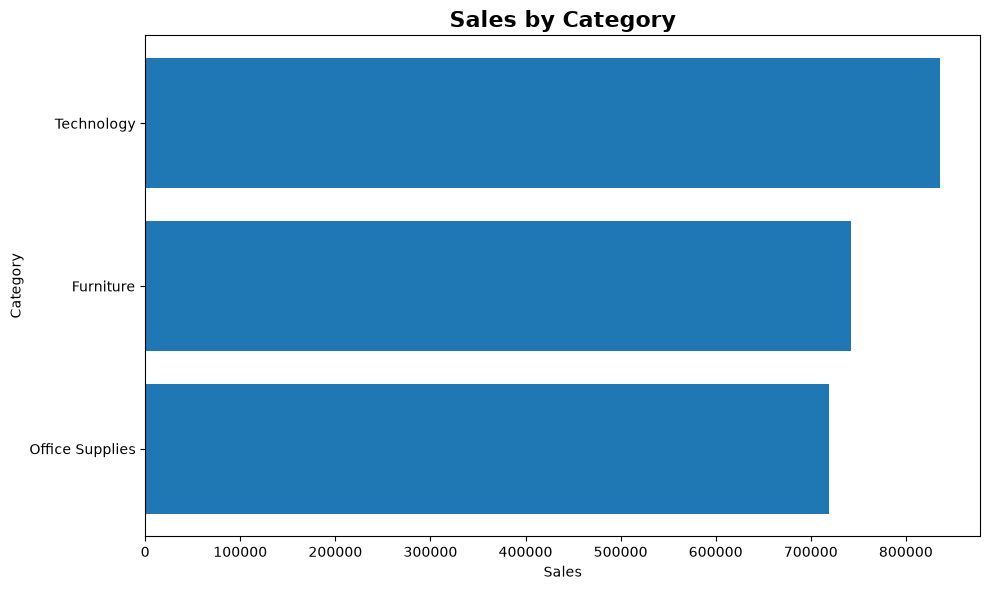

In [49]:
# Sales by Category

category_sales = (
    df.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 6))

plt.barh(
    category_sales.index,
    category_sales.values
)

plt.title("Sales by Category", fontsize=16, fontweight="bold")
plt.xlabel("Sales")
plt.ylabel("Category")

plt.tight_layout()

plt.savefig(
    "../screenshots/sales_by_category.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

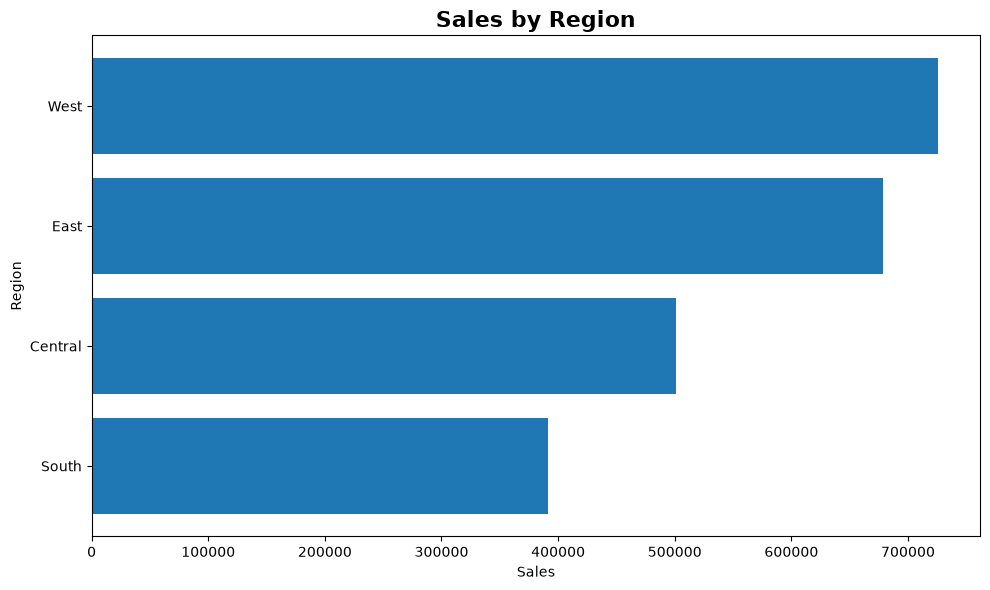

In [50]:
# Sales by Region

region_sales = (
    df.groupby("Region")["Sales"]
    .sum()
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 6))

plt.barh(
    region_sales.index,
    region_sales.values
)

plt.title("Sales by Region", fontsize=16, fontweight="bold")
plt.xlabel("Sales")
plt.ylabel("Region")

plt.tight_layout()

plt.savefig(
    "../screenshots/sales_by_region.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

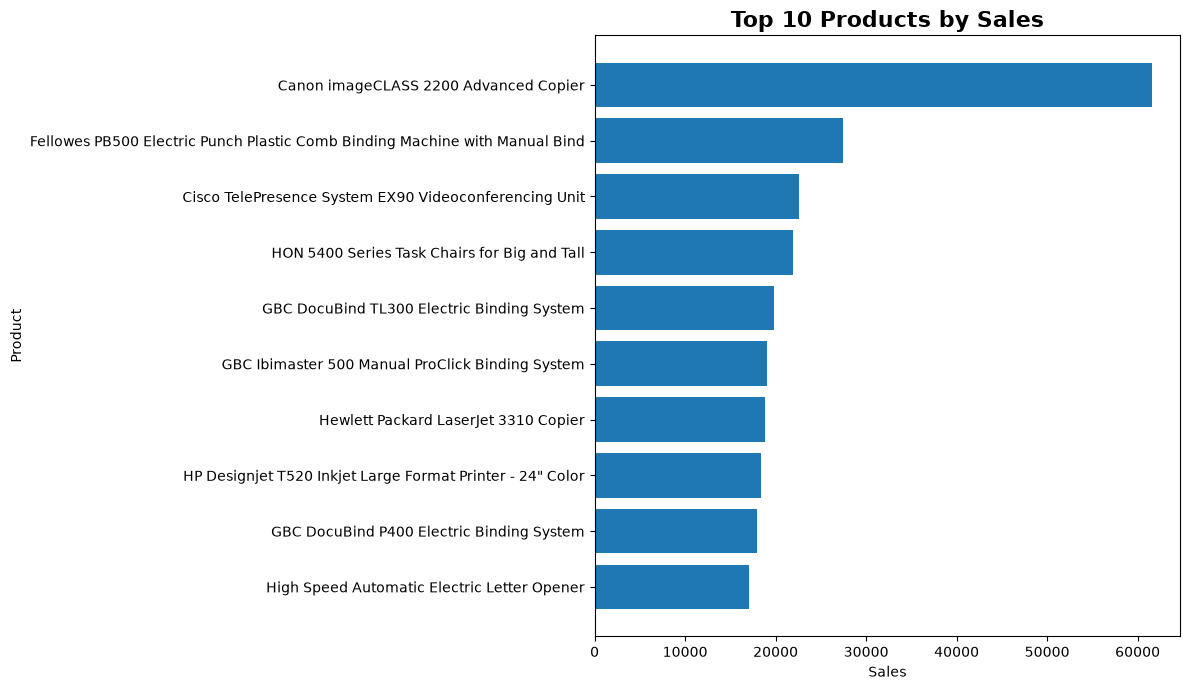

In [51]:
# Top 10 Products by Sales

top_10_products = (
    df.groupby("Product Name")["Sales"]
    .sum()
    .sort_values(ascending=True)
    .tail(10)
)

plt.figure(figsize=(12, 7))

plt.barh(
    top_10_products.index,
    top_10_products.values
)

plt.title(
    "Top 10 Products by Sales",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Sales")
plt.ylabel("Product")

plt.tight_layout()

plt.savefig(
    "../screenshots/top_10_products.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

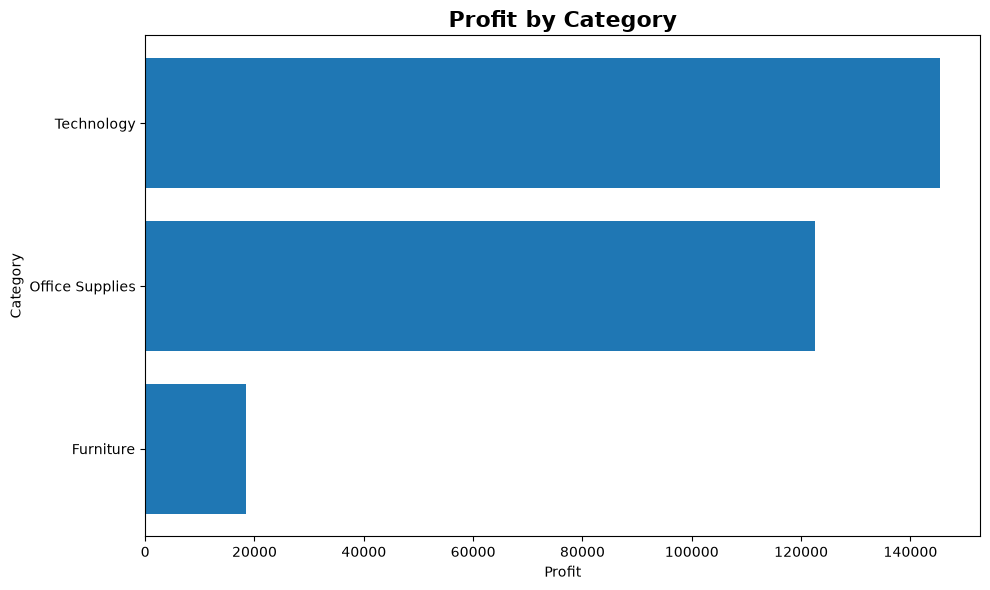

In [52]:
# Profit by Category

category_profit = (
    df.groupby("Category")["Profit"]
    .sum()
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 6))

plt.barh(
    category_profit.index,
    category_profit.values
)

plt.title("Profit by Category", fontsize=16, fontweight="bold")
plt.xlabel("Profit")
plt.ylabel("Category")

plt.tight_layout()

plt.savefig(
    "../screenshots/profit_by_category.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

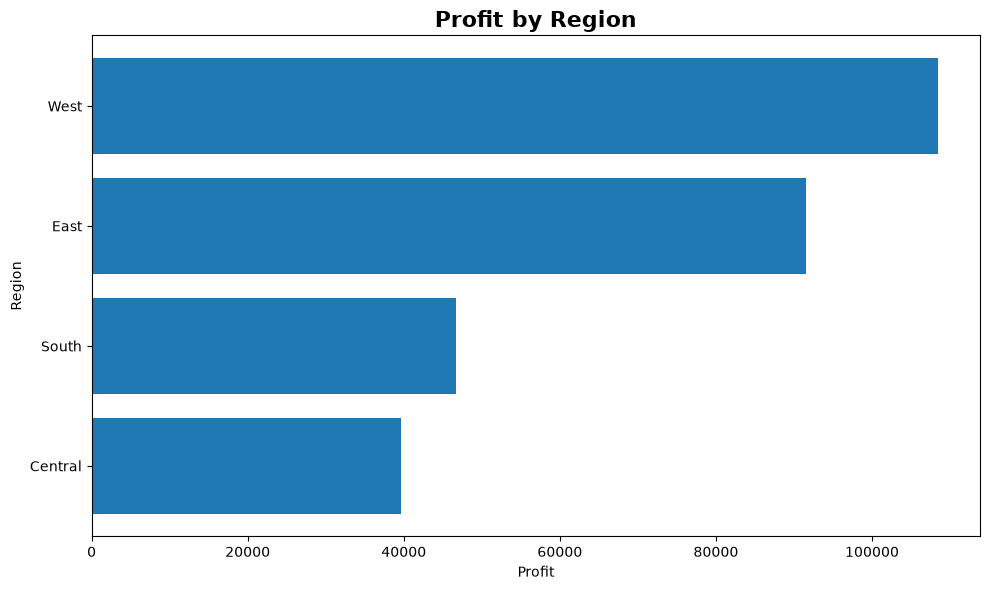

In [53]:
# Profit by Region

region_profit = (
    df.groupby("Region")["Profit"]
    .sum()
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 6))

plt.barh(
    region_profit.index,
    region_profit.values
)

plt.title("Profit by Region", fontsize=16, fontweight="bold")
plt.xlabel("Profit")
plt.ylabel("Region")

plt.tight_layout()

plt.savefig(
    "../screenshots/profit_by_region.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

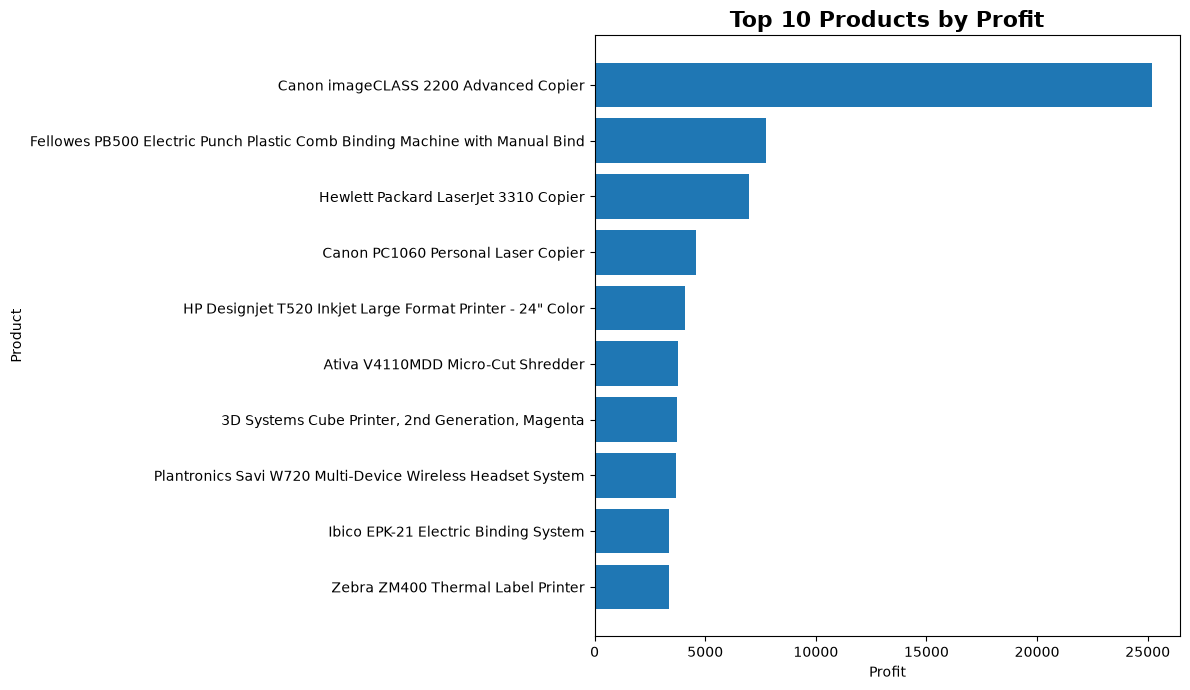

In [54]:
# Top 10 Products by Profit

top_10_profit_products = (
    df.groupby("Product Name")["Profit"]
    .sum()
    .sort_values(ascending=True)
    .tail(10)
)

plt.figure(figsize=(12, 7))

plt.barh(
    top_10_profit_products.index,
    top_10_profit_products.values
)

plt.title(
    "Top 10 Products by Profit",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Profit")
plt.ylabel("Product")

plt.tight_layout()

plt.savefig(
    "../screenshots/top_10_profit_products.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

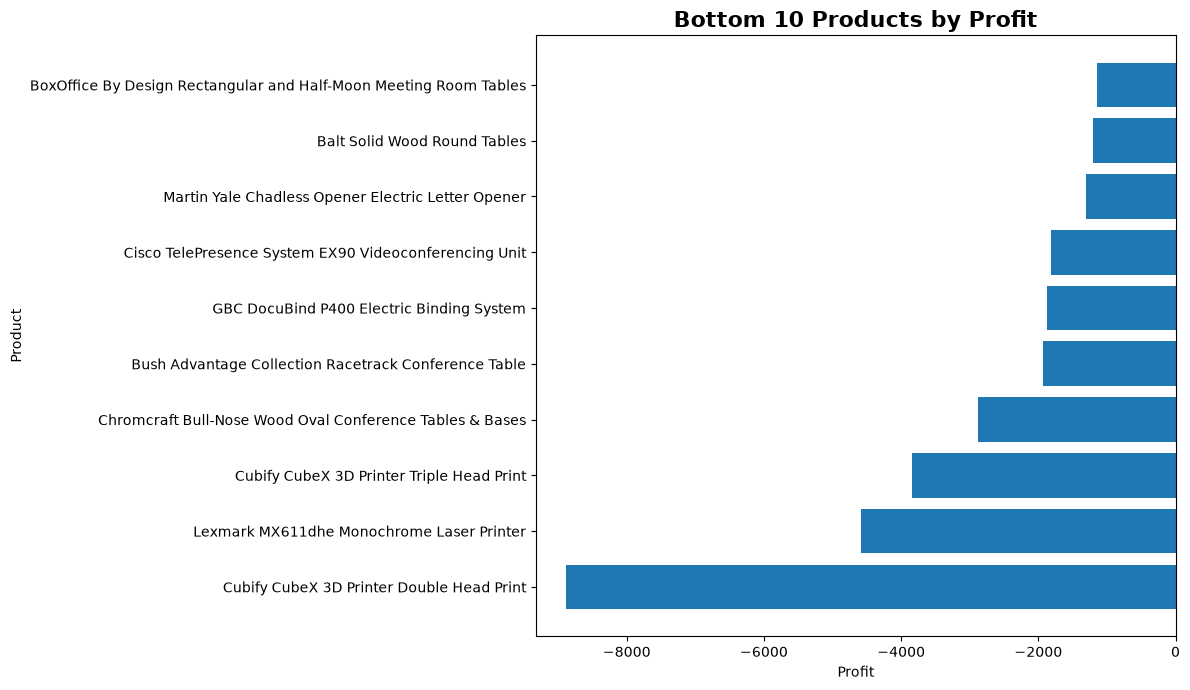

In [55]:
# Bottom 10 Products by Profit

bottom_10_profit_products = (
    df.groupby("Product Name")["Profit"]
    .sum()
    .sort_values(ascending=True)
    .head(10)
)

plt.figure(figsize=(12, 7))

plt.barh(
    bottom_10_profit_products.index,
    bottom_10_profit_products.values
)

plt.title(
    "Bottom 10 Products by Profit",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Profit")
plt.ylabel("Product")

plt.tight_layout()

plt.savefig(
    "../screenshots/bottom_10_profit_products.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [56]:
# Yearly Sales and Profit

yearly_performance = (
    df.groupby("Order Year")
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Profit", "sum")
    )
)

yearly_performance

,Total_Sales,Total_Profit
Order Year,,
2014,484247.4981,49543.9741
2015,470532.5090,61618.6037
2016,609205.5980,81795.1743
2017,733215.2552,93439.2696


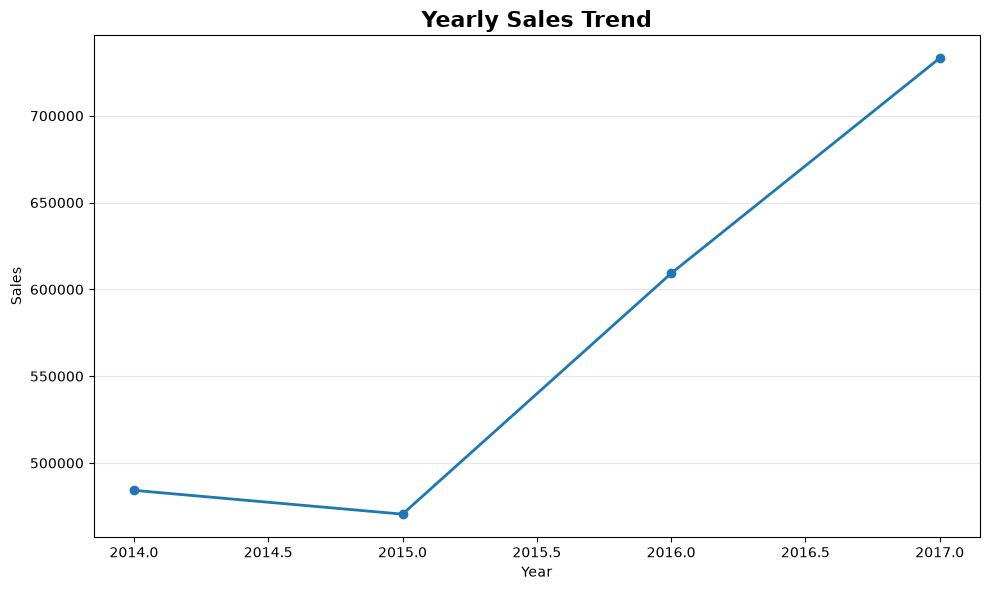

In [57]:
# Yearly Sales Trend

plt.figure(figsize=(10, 6))

plt.plot(
    yearly_performance.index,
    yearly_performance["Total_Sales"],
    marker="o",
    linewidth=2
)

plt.title("Yearly Sales Trend", fontsize=16, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("Sales")

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(
    "../screenshots/yearly_sales_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [58]:
# Create an analysis output folder

import os

os.makedirs("../data/analysis", exist_ok=True)

category_performance.to_csv(
    "../data/analysis/category_performance.csv"
)

regional_performance.to_csv(
    "../data/analysis/regional_performance.csv"
)

yearly_performance.to_csv(
    "../data/analysis/yearly_performance.csv"
)

top_products.to_csv(
    "../data/analysis/top_products.csv"
)

top_profit_products.to_csv(
    "../data/analysis/top_profit_products.csv"
)

print("Analysis tables exported successfully.")

Analysis tables exported successfully.


# Business Insights & Performance Findings

This section converts the analytical results into actionable business insights by identifying the strongest and weakest performing products, categories, regions, and years.

In [59]:
best_sales_category = category_performance["Total_Sales"].idxmax()
best_sales_category_value = category_performance["Total_Sales"].max()

print("Best Category by Sales")
print("----------------------")
print("Category:", best_sales_category)
print(f"Sales: ${best_sales_category_value:,.2f}")

Best Category by Sales
----------------------
Category: Technology
Sales: $836,154.03


In [60]:
best_profit_category = category_performance["Total_Profit"].idxmax()
best_profit_category_value = category_performance["Total_Profit"].max()

print("Best Category by Profit")
print("-----------------------")
print("Category:", best_profit_category)
print(f"Profit: ${best_profit_category_value:,.2f}")

Best Category by Profit
-----------------------
Category: Technology
Profit: $145,454.95


In [61]:
best_sales_region = regional_performance["Total_Sales"].idxmax()
best_sales_region_value = regional_performance["Total_Sales"].max()

print("Best Region by Sales")
print("--------------------")
print("Region:", best_sales_region)
print(f"Sales: ${best_sales_region_value:,.2f}")

Best Region by Sales
--------------------
Region: West
Sales: $725,457.82


In [62]:
best_profit_region = regional_performance["Total_Profit"].idxmax()
best_profit_region_value = regional_performance["Total_Profit"].max()

print("Best Region by Profit")
print("---------------------")
print("Region:", best_profit_region)
print(f"Profit: ${best_profit_region_value:,.2f}")

Best Region by Profit
---------------------
Region: West
Profit: $108,418.45


## Loss-Making Products

Products with negative total profit are identified to highlight potential pricing, discounting, cost, or product-mix issues.

In [63]:
loss_making_products = (
    df.groupby("Product Name")["Profit"]
    .sum()
    .sort_values()
)

loss_making_products = loss_making_products[
    loss_making_products < 0
]

print("Number of loss-making products:", len(loss_making_products))
print("\nBottom 10 Loss-Making Products:")
print(loss_making_products.head(10))

Number of loss-making products: 301

Bottom 10 Loss-Making Products:
Product Name
Cubify CubeX 3D Printer Double Head Print                           -8879.9704
Lexmark MX611dhe Monochrome Laser Printer                           -4589.9730
Cubify CubeX 3D Printer Triple Head Print                           -3839.9904
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases            -2876.1156
Bush Advantage Collection Racetrack Conference Table                -1934.3976
GBC DocuBind P400 Electric Binding System                           -1878.1662
Cisco TelePresence System EX90 Videoconferencing Unit               -1811.0784
Martin Yale Chadless Opener Electric Letter Opener                  -1299.1836
Balt Solid Wood Round Tables                                        -1201.0581
BoxOffice By Design Rectangular and Half-Moon Meeting Room Tables   -1148.4375
Name: Profit, dtype: float64


In [64]:
yearly_performance["Sales_Growth_%"] = (
    yearly_performance["Total_Sales"]
    .pct_change() * 100
)

yearly_performance["Profit_Growth_%"] = (
    yearly_performance["Total_Profit"]
    .pct_change() * 100
)

yearly_performance

,Total_Sales,Total_Profit,Sales_Growth_%,Profit_Growth_%
Order Year,,,,
2014,484247.4981,49543.9741,NaN,NaN
2015,470532.5090,61618.6037,-2.832227,24.371540
2016,609205.5980,81795.1743,29.471521,32.744284
2017,733215.2552,93439.2696,20.355962,14.235675


In [65]:
sales_growth_year = yearly_performance["Sales_Growth_%"].idxmax()
sales_growth_value = yearly_performance["Sales_Growth_%"].max()

profit_growth_year = yearly_performance["Profit_Growth_%"].idxmax()
profit_growth_value = yearly_performance["Profit_Growth_%"].max()

print("Strongest Sales Growth Year")
print("---------------------------")
print(f"Year: {sales_growth_year}")
print(f"Sales Growth: {sales_growth_value:.2f}%")

print("\nStrongest Profit Growth Year")
print("----------------------------")
print(f"Year: {profit_growth_year}")
print(f"Profit Growth: {profit_growth_value:.2f}%")

Strongest Sales Growth Year
---------------------------
Year: 2016
Sales Growth: 29.47%

Strongest Profit Growth Year
----------------------------
Year: 2016
Profit Growth: 32.74%


In [66]:
weakest_region = regional_performance["Total_Profit"].idxmin()
weakest_region_profit = regional_performance["Total_Profit"].min()

print("Weakest Region by Profit")
print("------------------------")
print("Region:", weakest_region)
print(f"Profit: ${weakest_region_profit:,.2f}")

Weakest Region by Profit
------------------------
Region: Central
Profit: $39,706.36


In [67]:
category_performance["Profit_Margin_%"] = (
    category_performance["Total_Profit"]
    / category_performance["Total_Sales"]
) * 100

category_performance.sort_values(
    "Profit_Margin_%",
    ascending=False
)

,Total_Sales,Total_Profit,Profit_Margin_%
Category,,,
Technology,836154.0330,145454.9481,17.395712
Office Supplies,719047.0320,122490.8008,17.035158
Furniture,741999.7953,18451.2728,2.486695


In [68]:
regional_performance["Profit_Margin_%"] = (
    regional_performance["Total_Profit"]
    / regional_performance["Total_Sales"]
) * 100

regional_performance.sort_values(
    "Profit_Margin_%",
    ascending=False
)

,Total_Sales,Total_Profit,Profit_Margin_%
Region,,,
West,725457.8245,108418.4489,14.944831
East,678781.2400,91522.7800,13.483399
South,391721.9050,46749.4303,11.934342
Central,501239.8908,39706.3625,7.921629


## Monthly Sales Trend Over Time

A chronological month-level analysis is created to identify actual sales movements and growth patterns over the study period.

In [69]:
monthly_trend = (
    df.assign(
        Order_Month_Date=df["Order Date"]
        .dt.to_period("M")
        .dt.to_timestamp()
    )
    .groupby("Order_Month_Date")
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Profit", "sum")
    )
    .reset_index()
)

monthly_trend.head()

,Order_Month_Date,Total_Sales,Total_Profit
0,2014-01-01,14236.895,2450.1907
1,2014-02-01,4519.892,862.3084
2,2014-03-01,55691.009,498.7299
3,2014-04-01,28295.345,3488.8352
4,2014-05-01,23648.287,2738.7096


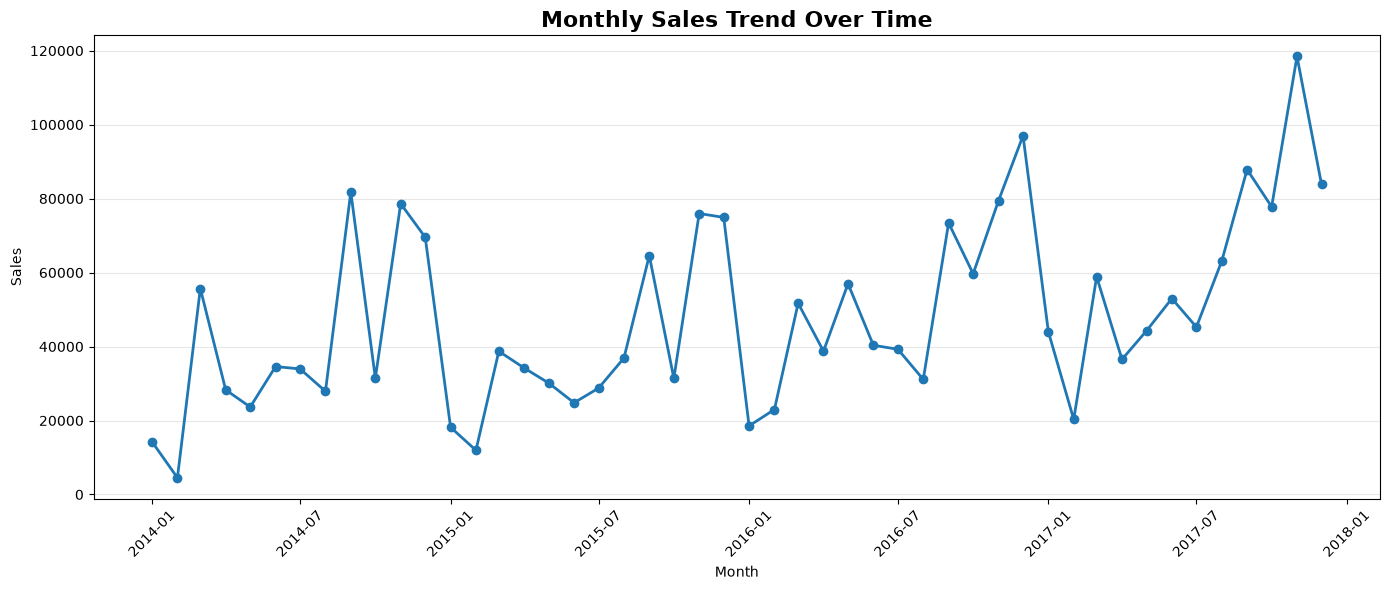

In [70]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_trend["Order_Month_Date"],
    monthly_trend["Total_Sales"],
    marker="o",
    linewidth=2
)

plt.title(
    "Monthly Sales Trend Over Time",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Month")
plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../screenshots/monthly_sales_trend_over_time.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [71]:
category_performance.to_csv(
    "../data/analysis/category_performance.csv"
)

regional_performance.to_csv(
    "../data/analysis/regional_performance.csv"
)

yearly_performance.to_csv(
    "../data/analysis/yearly_performance.csv"
)

loss_making_products.to_csv(
    "../data/analysis/loss_making_products.csv"
)

monthly_trend.to_csv(
    "../data/analysis/monthly_trend.csv",
    index=False
)

print("Updated analysis files exported successfully.")

Updated analysis files exported successfully.


# Executive Sales Performance Dashboard

This dashboard provides an executive-level overview of sales, profitability, product performance, regional performance, and business growth trends.

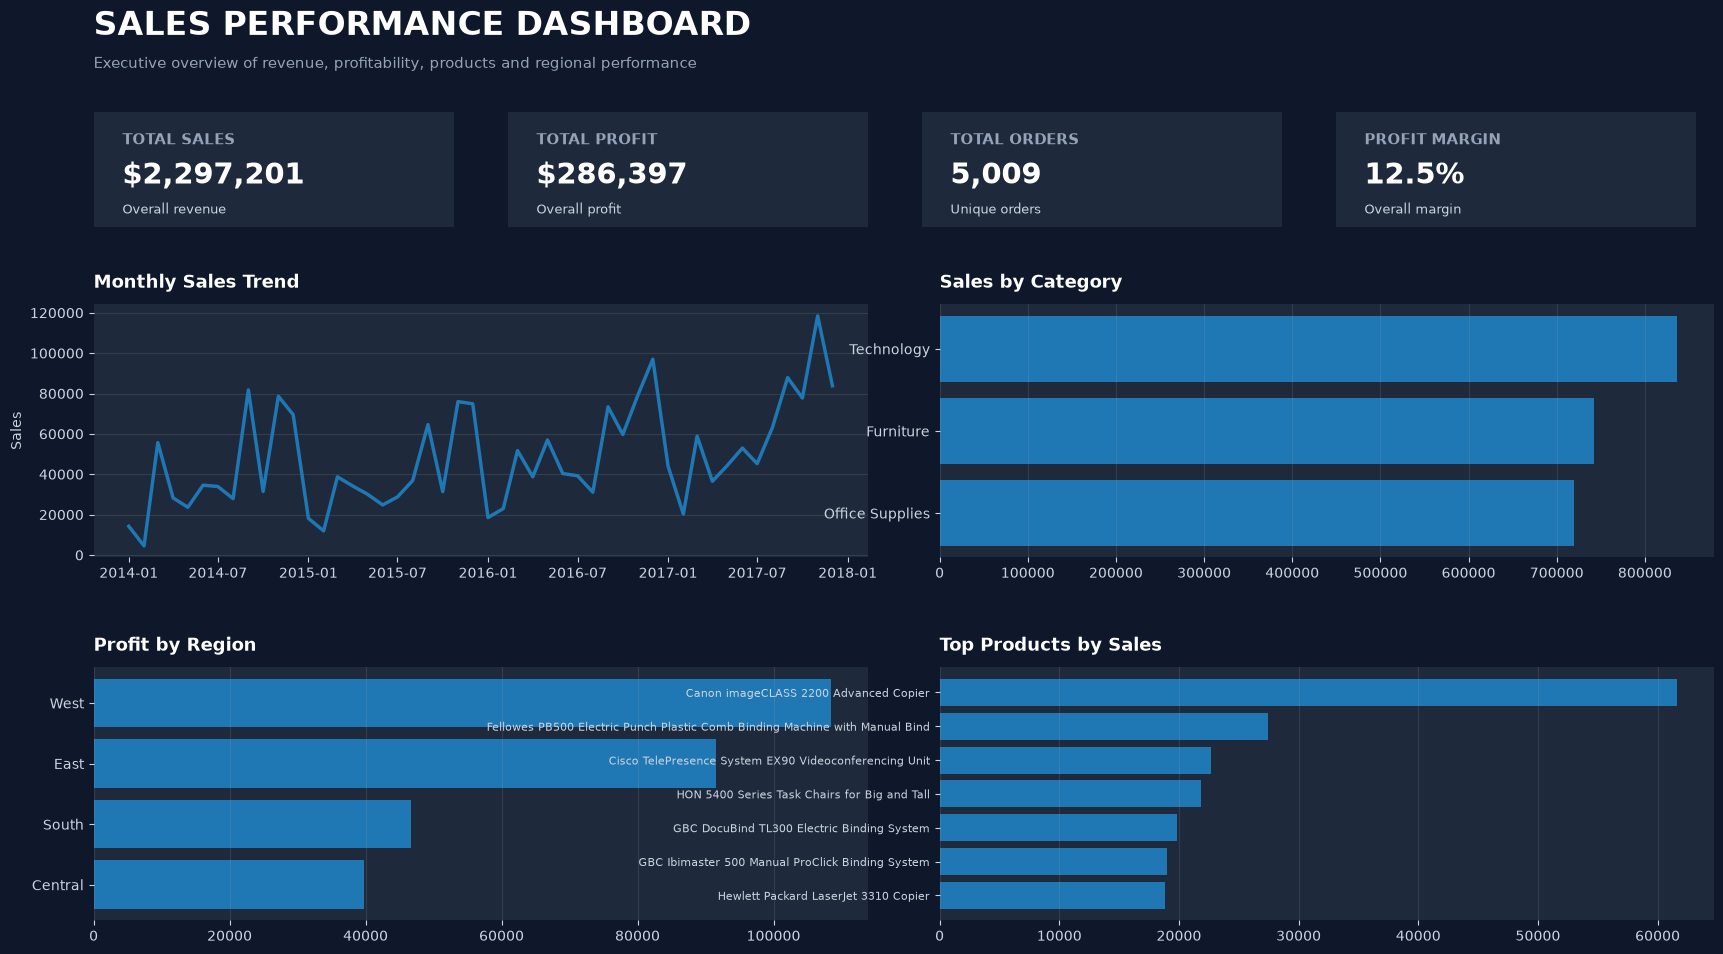

In [72]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
import numpy as np

# --------------------------------------------------
# Executive Dashboard
# --------------------------------------------------

fig = plt.figure(figsize=(18, 11))
fig.patch.set_facecolor("#0F172A")

# -----------------------------
# Helper function for KPI cards
# -----------------------------

def add_kpi_card(x, y, width, height, title, value, subtitle):
    ax = fig.add_axes([x, y, width, height])
    ax.set_facecolor("#1E293B")

    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.set_xticks([])
    ax.set_yticks([])

    ax.text(
        0.08, 0.72,
        title,
        fontsize=11,
        fontweight="bold",
        color="#94A3B8",
        transform=ax.transAxes
    )

    ax.text(
        0.08, 0.38,
        value,
        fontsize=21,
        fontweight="bold",
        color="white",
        transform=ax.transAxes
    )

    ax.text(
        0.08, 0.12,
        subtitle,
        fontsize=9,
        color="#CBD5E1",
        transform=ax.transAxes
    )

    return ax


# -----------------------------
# Dashboard title
# -----------------------------

fig.text(
    0.05, 0.955,
    "SALES PERFORMANCE DASHBOARD",
    fontsize=24,
    fontweight="bold",
    color="white"
)

fig.text(
    0.05, 0.925,
    "Executive overview of revenue, profitability, products and regional performance",
    fontsize=11,
    color="#94A3B8"
)


# -----------------------------
# KPI Cards
# -----------------------------

add_kpi_card(
    0.05, 0.78, 0.20, 0.105,
    "TOTAL SALES",
    f"${total_sales:,.0f}",
    "Overall revenue"
)

add_kpi_card(
    0.28, 0.78, 0.20, 0.105,
    "TOTAL PROFIT",
    f"${total_profit:,.0f}",
    "Overall profit"
)

add_kpi_card(
    0.51, 0.78, 0.20, 0.105,
    "TOTAL ORDERS",
    f"{total_orders:,}",
    "Unique orders"
)

add_kpi_card(
    0.74, 0.78, 0.20, 0.105,
    "PROFIT MARGIN",
    f"{profit_margin:.1f}%",
    "Overall margin"
)


# -----------------------------
# Monthly Sales Chart
# -----------------------------

ax1 = fig.add_axes([0.05, 0.48, 0.43, 0.23])
ax1.set_facecolor("#1E293B")

ax1.plot(
    monthly_trend["Order_Month_Date"],
    monthly_trend["Total_Sales"],
    linewidth=2.5
)

ax1.set_title(
    "Monthly Sales Trend",
    loc="left",
    fontsize=13,
    fontweight="bold",
    color="white",
    pad=12
)

ax1.tick_params(colors="#CBD5E1")
ax1.grid(axis="y", alpha=0.15)

for spine in ax1.spines.values():
    spine.set_visible(False)

ax1.set_xlabel("")
ax1.set_ylabel("Sales", color="#CBD5E1")


# -----------------------------
# Category Sales
# -----------------------------

ax2 = fig.add_axes([0.52, 0.48, 0.43, 0.23])
ax2.set_facecolor("#1E293B")

category_chart = (
    df.groupby("Category")["Sales"]
    .sum()
    .sort_values()
)

ax2.barh(
    category_chart.index,
    category_chart.values
)

ax2.set_title(
    "Sales by Category",
    loc="left",
    fontsize=13,
    fontweight="bold",
    color="white",
    pad=12
)

ax2.tick_params(colors="#CBD5E1")

for spine in ax2.spines.values():
    spine.set_visible(False)

ax2.grid(axis="x", alpha=0.15)


# -----------------------------
# Regional Profit
# -----------------------------

ax3 = fig.add_axes([0.05, 0.15, 0.43, 0.23])
ax3.set_facecolor("#1E293B")

region_chart = (
    df.groupby("Region")["Profit"]
    .sum()
    .sort_values()
)

ax3.barh(
    region_chart.index,
    region_chart.values
)

ax3.set_title(
    "Profit by Region",
    loc="left",
    fontsize=13,
    fontweight="bold",
    color="white",
    pad=12
)

ax3.tick_params(colors="#CBD5E1")

for spine in ax3.spines.values():
    spine.set_visible(False)

ax3.grid(axis="x", alpha=0.15)


# -----------------------------
# Top Products
# -----------------------------

ax4 = fig.add_axes([0.52, 0.15, 0.43, 0.23])
ax4.set_facecolor("#1E293B")

product_chart = (
    df.groupby("Product Name")["Sales"]
    .sum()
    .sort_values()
    .tail(7)
)

ax4.barh(
    product_chart.index,
    product_chart.values
)

ax4.set_title(
    "Top Products by Sales",
    loc="left",
    fontsize=13,
    fontweight="bold",
    color="white",
    pad=12
)

ax4.tick_params(
    axis="y",
    labelsize=8,
    colors="#CBD5E1"
)

ax4.tick_params(
    axis="x",
    colors="#CBD5E1"
)

for spine in ax4.spines.values():
    spine.set_visible(False)

ax4.grid(axis="x", alpha=0.15)


# -----------------------------
# Save dashboard
# -----------------------------

plt.savefig(
    "../screenshots/executive_sales_dashboard.png",
    dpi=300,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

plt.show()

# Business Insights

This section presents the most important findings from the sales analysis in an executive-friendly format.

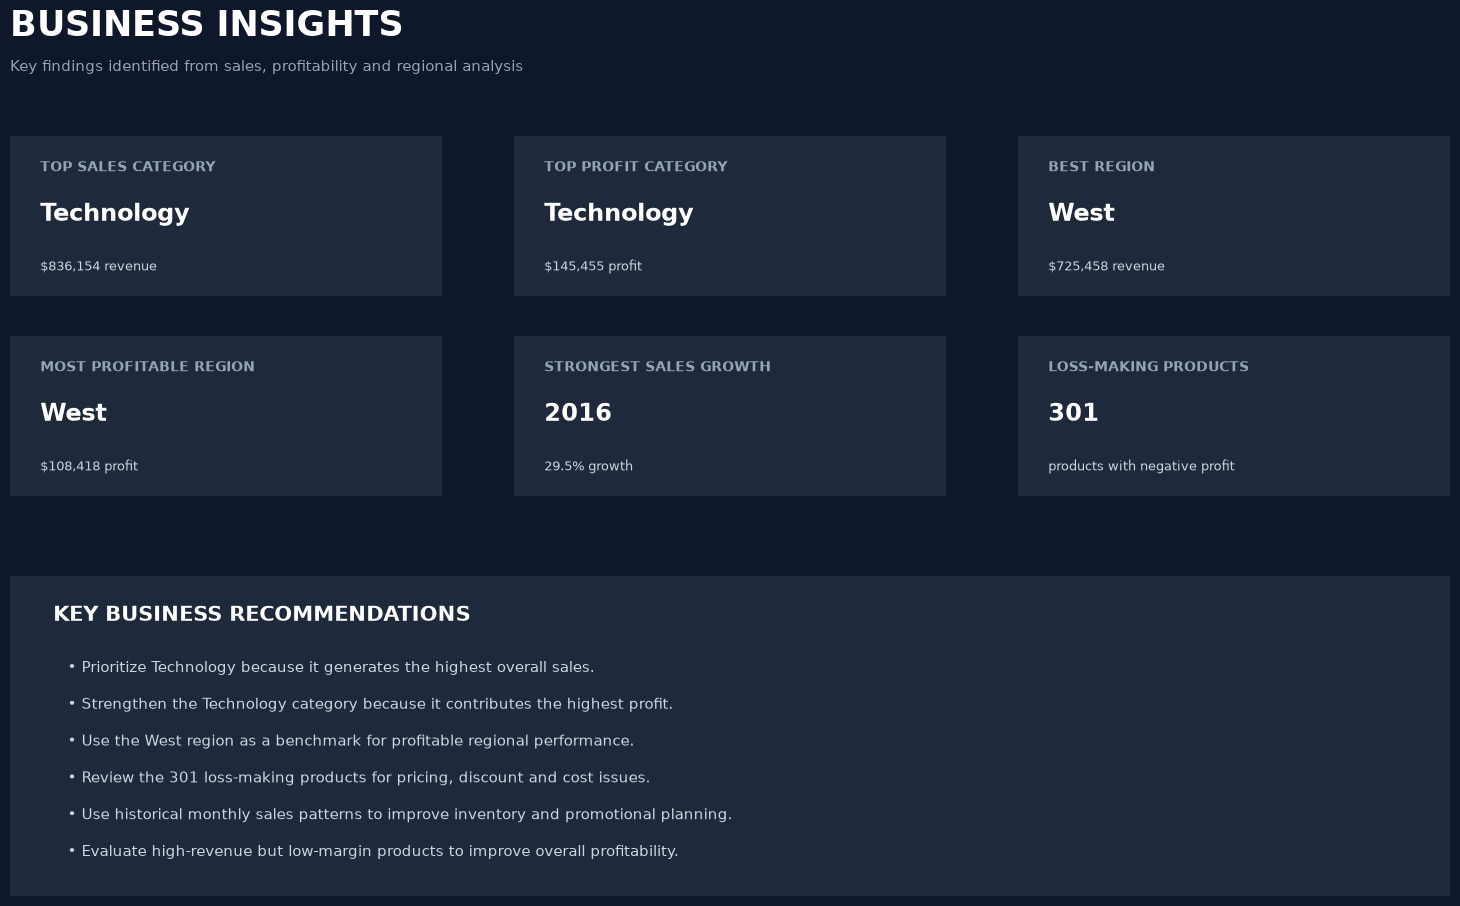

In [73]:
# --------------------------------------------------
# BUSINESS INSIGHTS VISUAL PAGE
# --------------------------------------------------

import matplotlib.pyplot as plt

fig = plt.figure(figsize=(16, 10))
fig.patch.set_facecolor("#0F172A")


# --------------------------------------------------
# Helper function
# --------------------------------------------------

def insight_card(x, y, width, height, label, value, description):
    ax = fig.add_axes([x, y, width, height])
    ax.set_facecolor("#1E293B")

    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.set_xticks([])
    ax.set_yticks([])

    ax.text(
        0.07, 0.78,
        label,
        fontsize=10,
        fontweight="bold",
        color="#94A3B8",
        transform=ax.transAxes
    )

    ax.text(
        0.07, 0.47,
        value,
        fontsize=17,
        fontweight="bold",
        color="white",
        transform=ax.transAxes
    )

    ax.text(
        0.07, 0.16,
        description,
        fontsize=9,
        color="#CBD5E1",
        transform=ax.transAxes
    )


# --------------------------------------------------
# Header
# --------------------------------------------------

fig.text(
    0.05, 0.94,
    "BUSINESS INSIGHTS",
    fontsize=25,
    fontweight="bold",
    color="white"
)

fig.text(
    0.05, 0.905,
    "Key findings identified from sales, profitability and regional analysis",
    fontsize=11,
    color="#94A3B8"
)


# --------------------------------------------------
# Insight Cards
# --------------------------------------------------

insight_card(
    0.05, 0.68, 0.27, 0.16,
    "TOP SALES CATEGORY",
    best_sales_category,
    f"${best_sales_category_value:,.0f} revenue"
)

insight_card(
    0.365, 0.68, 0.27, 0.16,
    "TOP PROFIT CATEGORY",
    best_profit_category,
    f"${best_profit_category_value:,.0f} profit"
)

insight_card(
    0.68, 0.68, 0.27, 0.16,
    "BEST REGION",
    best_sales_region,
    f"${best_sales_region_value:,.0f} revenue"
)


# --------------------------------------------------
# Second Row
# --------------------------------------------------

insight_card(
    0.05, 0.48, 0.27, 0.16,
    "MOST PROFITABLE REGION",
    best_profit_region,
    f"${best_profit_region_value:,.0f} profit"
)

insight_card(
    0.365, 0.48, 0.27, 0.16,
    "STRONGEST SALES GROWTH",
    str(sales_growth_year),
    f"{sales_growth_value:.1f}% growth"
)

insight_card(
    0.68, 0.48, 0.27, 0.16,
    "LOSS-MAKING PRODUCTS",
    str(len(loss_making_products)),
    "products with negative profit"
)


# --------------------------------------------------
# Recommendations Section
# --------------------------------------------------

recommendation_ax = fig.add_axes(
    [0.05, 0.08, 0.90, 0.32]
)

recommendation_ax.set_facecolor("#1E293B")

for spine in recommendation_ax.spines.values():
    spine.set_visible(False)

recommendation_ax.set_xticks([])
recommendation_ax.set_yticks([])


recommendation_ax.text(
    0.03, 0.86,
    "KEY BUSINESS RECOMMENDATIONS",
    fontsize=15,
    fontweight="bold",
    color="white",
    transform=recommendation_ax.transAxes
)


recommendations = [
    f"Prioritize {best_sales_category} because it generates the highest overall sales.",
    
    f"Strengthen the {best_profit_category} category because it contributes the highest profit.",
    
    f"Use the {best_profit_region} region as a benchmark for profitable regional performance.",
    
    f"Review the {len(loss_making_products)} loss-making products for pricing, discount and cost issues.",
    
    "Use historical monthly sales patterns to improve inventory and promotional planning.",
    
    "Evaluate high-revenue but low-margin products to improve overall profitability."
]


for i, recommendation in enumerate(recommendations):

    y_position = 0.70 - (i * 0.115)

    recommendation_ax.text(
        0.04,
        y_position,
        f"• {recommendation}",
        fontsize=10.5,
        color="#CBD5E1",
        transform=recommendation_ax.transAxes
    )


# --------------------------------------------------
# Save
# --------------------------------------------------

plt.savefig(
    "../screenshots/business_insights.png",
    dpi=300,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

plt.show()